In [2]:
from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path
import math

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd


Using the requested 2025-09-23 10:00 to 2025-09-24 10:00 UTC window directly on the CSV `timestamp_utc` values.
Shared hexbin LogNorm range for color scale: vmin=1, vmax=210


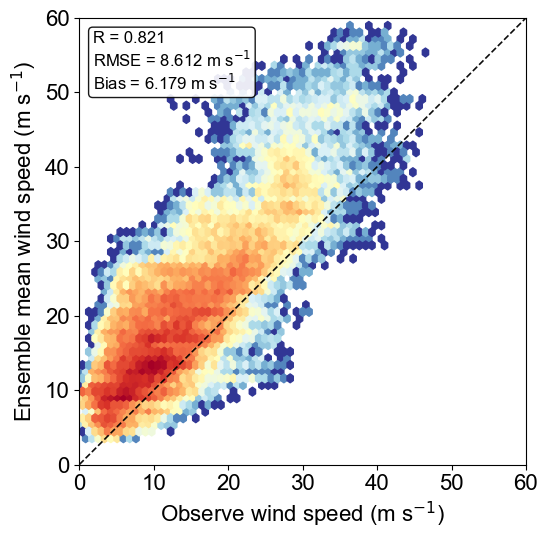

24h mean_wspd: saved meanwspd_obs_vs_multi_ai_hexbin_24h_20250923-10_to_20250924-10.tif with 43,092 paired station-time samples.


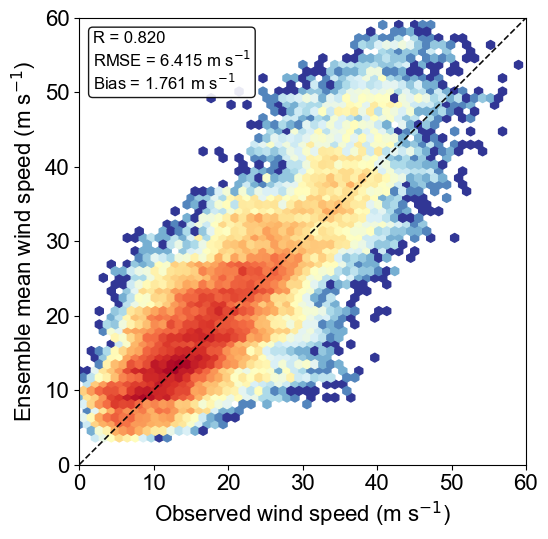

24h max_wspd: saved maxwspd_obs_vs_multi_ai_hexbin_24h_20250923-10_to_20250924-10.tif with 43,170 paired station-time samples.


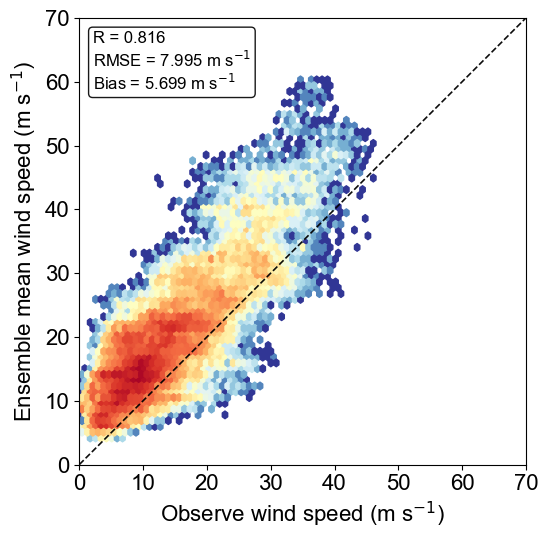

48h mean_wspd: saved meanwspd_obs_vs_multi_ai_hexbin_48h_20250923-10_to_20250924-10.tif with 43,092 paired station-time samples.


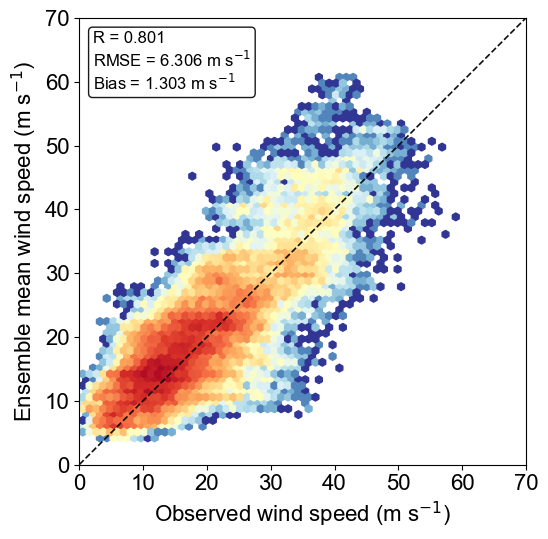

48h max_wspd: saved maxwspd_obs_vs_multi_ai_hexbin_48h_20250923-10_to_20250924-10.tif with 43,170 paired station-time samples.


In [3]:
from __future__ import annotations

try:
    SCRIPT_DIR = Path(__file__).resolve().parent
except NameError:
    SCRIPT_DIR = Path.cwd()

DATA_DIR = SCRIPT_DIR / "data" / "obs_sim"
OUTPUT_DIR = SCRIPT_DIR / "publish"

AI_MODELS = ["pangu", "graphcast", "fengwu", "fuxi", "aurora"]
WINDOW_START_UTC = datetime(2025, 9, 23, 10, 0, tzinfo=timezone.utc)
WINDOW_END_UTC = datetime(2025, 9, 24, 10, 0, tzinfo=timezone.utc)

FIGSIZE = (6.2, 5.8)
GRIDSIZE = 55
STATS_FONTSIZE = 12

HEXBIN_CMAP = "RdYlBu_r"

COLORBAR_LABEL = "Counts"

TICK_INTERVAL = 10


def configure_matplotlib() -> None:
    plt.rcParams.update(
        {
            "font.family": "Arial",
            "font.size": 16,
            "axes.labelsize": 16,
            "xtick.labelsize": 16,
            "ytick.labelsize": 16,
        }
    )


configure_matplotlib()


@dataclass(frozen=True)
class ForecastFiles:
    lead_hours: int
    variable: str
    obs_path: Path
    sim_path: Path
    output_path: Path


def build_file_config(lead_hours: int, variable: str) -> ForecastFiles:
    window_text = f"{WINDOW_START_UTC:%Y%m%d-%H}_to_{WINDOW_END_UTC:%Y%m%d-%H}"

    output_prefix = {
        "mean_wspd": "meanwspd",
        "max_wspd": "maxwspd",
    }.get(variable, variable.replace("_", ""))

    filename = f"{output_prefix}_obs_vs_multi_ai_hexbin_{lead_hours}h_{window_text}.tif"

    return ForecastFiles(
        lead_hours=lead_hours,
        variable=variable,
        obs_path=(
            DATA_DIR
            / "results_obs_newT_flattened"
            / f"{variable}_obs_{lead_hours}h_flattened.csv"
        ),
        sim_path=(
            DATA_DIR
            / "results_sim_newT_flattened"
            / f"{variable}_sim_{lead_hours}h_flattened.csv"
        ),
        output_path=OUTPUT_DIR / filename,
    )


def read_flattened_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "timestamp_utc" not in df.columns:
        raise ValueError(f"`timestamp_utc` is missing in {path}")

    df["timestamp_utc"] = pd.to_datetime(
        df["timestamp_utc"], format="%Y%m%d %H%M", utc=True
    )
    df["sample_index"] = df.groupby("timestamp_utc").cumcount()
    return df


def load_paired_samples(files: ForecastFiles) -> pd.DataFrame:
    obs = read_flattened_csv(files.obs_path)
    if files.variable not in obs.columns:
        raise ValueError(f"`{files.variable}` is missing in {files.obs_path}")
    obs = obs.rename(columns={files.variable: "observed_value"})

    sim = read_flattened_csv(files.sim_path)
    missing_models = [model for model in AI_MODELS if model not in sim.columns]
    if missing_models:
        raise ValueError(
            f"Missing AI model columns in {files.sim_path}: {', '.join(missing_models)}"
        )

    sim["multi_ai_mean"] = sim[AI_MODELS].mean(axis=1)
    merged = obs.merge(
        sim[["timestamp_utc", "sample_index", "multi_ai_mean"]],
        on=["timestamp_utc", "sample_index"],
        how="inner",
        validate="one_to_one",
    )

    if len(merged) != len(obs) or len(merged) != len(sim):
        raise ValueError(
            "Obs/sim pairing dropped samples after merging on flattened order. "
            f"obs={len(obs):,}, sim={len(sim):,}, merged={len(merged):,}."
        )

    filtered = merged.loc[
        (merged["timestamp_utc"] >= WINDOW_START_UTC)
        & (merged["timestamp_utc"] <= WINDOW_END_UTC),
        ["timestamp_utc", "observed_value", "multi_ai_mean"],
    ].dropna()

    if filtered.empty:
        available_start = merged["timestamp_utc"].min()
        available_end = merged["timestamp_utc"].max()
        raise ValueError(
            "No paired samples found in the requested UTC window "
            f"{WINDOW_START_UTC:%Y-%m-%d %H:%M} to {WINDOW_END_UTC:%Y-%m-%d %H:%M}. "
            f"Available UTC range is {available_start:%Y-%m-%d %H:%M} "
            f"to {available_end:%Y-%m-%d %H:%M}."
        )

    return filtered


def compute_stats(observed: np.ndarray, predicted: np.ndarray) -> tuple[float, float, float]:
    correlation = float(np.corrcoef(observed, predicted)[0, 1])
    rmse = float(np.sqrt(np.mean((predicted - observed) ** 2)))
    bias = float(np.mean(predicted - observed))
    return correlation, rmse, bias


def log10_ticks_from_range(vmin: float, vmax: float) -> list[float]:
    if not (math.isfinite(vmin) and math.isfinite(vmax)) or vmin <= 0 or vmax <= 0:
        return [1.0]
    if vmax < vmin:
        vmin, vmax = vmax, vmin

    pmin = int(math.floor(math.log10(vmin)))
    pmax = int(math.ceil(math.log10(vmax)))
    ticks = [float(10**p) for p in range(pmin, pmax + 1)]
    return [t for t in ticks if vmin <= t <= vmax]


def compute_global_hexbin_count_range(
    lead_hours_values: tuple[int, ...],
    variables: tuple[str, ...],
) -> tuple[float, float]:
    global_vmin = 1.0
    global_vmax = 1.0

    for lead_hours in lead_hours_values:
        for variable in variables:
            files = build_file_config(lead_hours, variable)
            samples = load_paired_samples(files)
            observed = samples["observed_value"].to_numpy()
            predicted = samples["multi_ai_mean"].to_numpy()

            fig, ax = plt.subplots(figsize=(1, 1))
            hb = ax.hexbin(
                observed,
                predicted,
                gridsize=GRIDSIZE,
                mincnt=1,
                cmap=HEXBIN_CMAP,
                norm=LogNorm(),
            )
            counts = np.asarray(hb.get_array())
            if counts.size:
                global_vmax = max(global_vmax, float(np.nanmax(counts)))
            plt.close(fig)

    return global_vmin, global_vmax


def labels_for_variable(variable: str) -> tuple[str, str]:
    if variable == "mean_wspd":
        x_label = "Observe wind speed (m s$^{-1}$)"
        y_label = "Ensemble mean wind speed (m s$^{-1}$)"
        return x_label, y_label

    if variable == "max_wspd":
        x_label = "Observed wind speed (m s$^{-1}$)"
        y_label = "Ensemble mean wind speed (m s$^{-1}$)"
        return x_label, y_label

    x_label = "Observed wind speed (m s$^{-1}$)"
    y_label = "Ensemble mean wind speed (m s$^{-1}$)"
    return x_label, y_label


def plot_hexbin(
    samples: pd.DataFrame,
    files: ForecastFiles,
    *,
    norm=None,
    show: bool = True,
) -> None:
    observed = samples["observed_value"].to_numpy()
    predicted = samples["multi_ai_mean"].to_numpy()
    correlation, rmse, bias = compute_stats(observed, predicted)

    axis_max = float(np.nanmax([observed.max(), predicted.max()]))
    axis_max = max(1.0, axis_max)
    axis_max = int(math.ceil(axis_max / TICK_INTERVAL) * TICK_INTERVAL)

    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.hexbin(
        observed,
        predicted,
        gridsize=GRIDSIZE,
        mincnt=1,
        cmap=HEXBIN_CMAP,
        norm=norm if norm is not None else LogNorm(),
    )

    ax.plot(
        [0, axis_max],
        [0, axis_max],
        linestyle="--",
        linewidth=1.2,
        color="black",
        alpha=0.95,
    )

    ax.set_xlim(0, axis_max)
    ax.set_ylim(0, axis_max)
    ax.set_aspect("equal", adjustable="box")
    ticks = np.arange(0, axis_max + TICK_INTERVAL, TICK_INTERVAL)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    x_label, y_label = labels_for_variable(files.variable)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    stats_text = "\n".join(
        [
            f"R = {correlation:.3f}",
            f"RMSE = {rmse:.3f} m s$^{{-1}}$",
            f"Bias = {bias:.3f} m s$^{{-1}}$",
        ]
    )
    ax.text(
        0.03,
        0.97,
        stats_text,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=STATS_FONTSIZE,
        bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.9},
    )

    files.output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(files.output_path, dpi=600, bbox_inches="tight")

    if show:
        plt.show()

    plt.close(fig)


def main(*, show: bool = True) -> LogNorm:
    print(
        "Using the requested 2025-09-23 10:00 to 2025-09-24 10:00 UTC window "
        "directly on the CSV `timestamp_utc` values." 
    )

    lead_hours_values = (24, 48)
    variables = ("mean_wspd", "max_wspd")
    vmin, vmax = compute_global_hexbin_count_range(lead_hours_values, variables)
    shared_norm = LogNorm(vmin=vmin, vmax=vmax)
    print(f"Shared hexbin LogNorm range for color scale: vmin={vmin:g}, vmax={vmax:g}")

    for lead_hours in lead_hours_values:
        for variable in variables:
            files = build_file_config(lead_hours, variable)
            samples = load_paired_samples(files)
            plot_hexbin(samples, files, norm=shared_norm, show=show)
            print(
                f"{lead_hours}h {variable}: saved {files.output_path.name} with "
                f"{len(samples):,} paired station-time samples."
            )

    return shared_norm


HEXBIN_NORM = main(show=True)


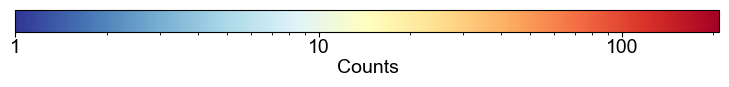

Saved standalone colorbar: e:\CityU\Paper Code\06_AI_WRF_UCM\Figs\Fig4\publish\hexbin_counts_colorbar_horizontal.tif


WindowsPath('e:/CityU/Paper Code/06_AI_WRF_UCM/Figs/Fig4/publish/hexbin_counts_colorbar_horizontal.tif')

In [5]:
from matplotlib.cm import ScalarMappable


def draw_standalone_horizontal_colorbar(*, show: bool = True) -> Path:
    """Draw a shared horizontal colorbar for the hexbin plots (long and thin)."""
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    out_path = OUTPUT_DIR / "hexbin_counts_colorbar_horizontal.tif"

    try:
        norm = HEXBIN_NORM
    except NameError:
        # Fallback if this cell is run before the plotting cell.
        vmin, vmax = compute_global_hexbin_count_range((24, 48), ("mean_wspd", "max_wspd"))
        norm = LogNorm(vmin=vmin, vmax=vmax)

    sm = ScalarMappable(norm=norm, cmap=HEXBIN_CMAP)
    sm.set_array([])

    # Long + thin canvas; create a dedicated axes for the bar.
    fig = plt.figure(figsize=(8, 0.8))
    cax = fig.add_axes([0.06, 0.45, 0.88, 0.28])

    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.set_label(COLORBAR_LABEL, fontsize=14, labelpad=2)
    cbar.ax.tick_params(labelsize=14, pad=1)

    ticks = log10_ticks_from_range(float(norm.vmin), float(norm.vmax))
    cbar.set_ticks(ticks)
    cbar.ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:g}"))
    cbar.ax.xaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
    cbar.ax.xaxis.set_minor_formatter(mticker.NullFormatter())

    fig.savefig(out_path, dpi=600, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

    print(f"Saved standalone colorbar: {out_path}")
    return out_path


draw_standalone_horizontal_colorbar(show=True)